In [ ]:
'''
Question 1:

A retail store wants to identify customers who make frequent purchases. 
Given the dataset below, write a code to:
Group customers by their IDs.
Calculate the total number of purchases per customer.
Identify the top 3 frequent customers.
'''

In [14]:
import pandas as pd
data = {'Customer_ID': [101, 102, 103, 101, 104, 102, 101, 105, 102, 103],
        'Purchase_Amount': [200, 150, 180, 220, 300, 200, 100, 400, 250, 300]}
df=pd.DataFrame(data)
print("Total Purchases per Customer:")
df.groupby('Customer_ID', as_index=False).sum()



Total Purchases per Customer:


,Customer_ID,Purchase_Amount
0,101,520
1,102,600
2,103,480
3,104,300
4,105,400


In [17]:
print("Total number of purchases per customer:")
df['Customer_ID'].value_counts().reset_index().rename(columns={'index':'Customer_ID','Customer_ID':'Total No of purchases'})

Total number of purchases per customer:


,Customer_ID,Total No of purchases
0,101,3
1,102,3
2,103,2
3,104,1
4,105,1


In [46]:
print("Top 3 Frequent Customers:")
top_Customer_ID= df['Customer_ID'].value_counts().head(3).index
#top_Customer_ID
top_3_data = df[df['Customer_ID'].isin(top_Customer_ID)]
top_3_data.groupby('Customer_ID', as_index=False).sum().sort_values(by='Purchase_Amount',ascending=False)

Top 3 Frequent Customers:


,Customer_ID,Purchase_Amount
1,102,600
0,101,520
2,103,480


In [ ]:
'''Question 2:
A company tracks the daily sales of a product over a month. You are tasked with identifying any abnormal sales data using the IQR (Interquartile Range) method.
Dataset (Daily Sales in Units):

data = {'Day': range(1, 31),
        'Sales': [25, 30, 28, 45, 55, 60, 22, 80, 95, 120,
                  33, 29, 27, 35, 40, 50, 85, 110, 105, 92,
                  30, 34, 31, 33, 36, 42, 44, 48, 90, 200]}

Tasks:
1. Calculate the Q1 (25th percentile) and Q3 (75th percentile).
2. Determine the IQR.
3. Identify the Lower Bound and Upper Bound.
4. Detect and display the outliers.
5. Replace the Outliers with the Median Value.
'''

In [93]:
import numpy as np
import pandas as pd

data = {'Day': range(1, 31),
        'Sales': [25, 30, 28, 45, 55, 60, 22, 80, 95, 120,
                  33, 29, 27, 35, 40, 50, 85, 110, 105, 92,
                  30, 34, 31, 33, 36, 42, 44, 48, 90, 200]}

df=pd.DataFrame(data)

#1. Calculate the Q1 (25th percentile) and Q3 (75th percentile).
Q1,Q3 = np.percentile(df['Sales'],[25,75])
#2. Determine the IQR.
IQR= Q3 - Q1
print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
#3. Identify the Lower Bound and Upper Bound.
Lower_bound=Q1-1.5*IQR
Upper_bound=Q3+1.5*IQR

print(f"Lower_bound: {Lower_bound}, Upper_bound: {Upper_bound}")

#4. Detect and display the outliers.

Outliers = df[ (df['Sales']<Lower_bound) | (df['Sales']> Upper_bound) ] 

print("\nOutliers Detected:")
print(Outliers)

#5. Replace the Outliers with the Median Value

df.loc[(df['Sales']<Lower_bound) | (df['Sales']> Upper_bound), 'Sales'] = df['Sales'].median()
print(f"\nData After Replacing Outliers with Median:\n{df}")

Q1: 31.5, Q3: 83.75, IQR: 52.25
Lower_bound: -46.875, Upper_bound: 162.125

Outliers Detected:
    Day  Sales
29   30    200

Data After Replacing Outliers with Median:
    Day  Sales
0     1   25.0
1     2   30.0
2     3   28.0
3     4   45.0
4     5   55.0
5     6   60.0
6     7   22.0
7     8   80.0
8     9   95.0
9    10  120.0
10   11   33.0
11   12   29.0
12   13   27.0
13   14   35.0
14   15   40.0
15   16   50.0
16   17   85.0
17   18  110.0
18   19  105.0
19   20   92.0
20   21   30.0
21   22   34.0
22   23   31.0
23   24   33.0
24   25   36.0
25   26   42.0
26   27   44.0
27   28   48.0
28   29   90.0
29   30   43.0


In [ ]:
'''Question 3:  
A pharmaceutical company is testing the effectiveness of a new drug to reduce blood pressure. Two groups of patients were selected:
Group 1 (Treatment): Received the drug
Group 2 (Control): Received a placebo
The company wants to check if there is a significant difference in the blood pressure levels between the two groups using an Independent T-Test.
Dataset:
data = {'Group': ['Treatment']*10 + ['Control']*10,
        'Blood_Pressure': [120, 115, 118, 123, 122, 119, 124, 117, 116, 121,
                            130, 135, 140, 138, 142, 136, 139, 134, 137, 141]}
Tasks:
Perform an Independent T-Test.
State the null and alternative hypotheses.
Calculate the p-value.
Conclude whether the drug has a significant effect.'''

In [94]:
import pandas as pd

data = {'Group': ['Treatment']*10 + ['Control']*10,
        'Blood_Pressure': [120, 115, 118, 123, 122, 119, 124, 117, 116, 121,
                            130, 135, 140, 138, 142, 136, 139, 134, 137, 141]}

df=pd.DataFrame(data)

In [106]:
#Perform an Independent T-Test (Since there is a comparison between two categorical variables)
#State the null and alternative hypotheses.

#H0- Null Hypothesis -  The drug has no significant effect on reducing blood pressure
##H1- Alternate Hypothesis -  The drug has a significant effect on reducing blood pressure

from scipy.stats import ttest_ind
Treatment=df[df['Group']=='Treatment']['Blood_Pressure']
Control=df[df['Group']=='Control']['Blood_Pressure']
static_value,p_value = ttest_ind(Treatment,Control)
print(f"static_value:{static_value},  p_value:{p_value}")
p_value

#Conclude whether the drug has a significant effect
if p_value <= 0.05:
    print("Null hypothesis is rejected: The drug has a significant effect.")
else:
    print("Null hypothesis is accepted: The drug has no significant effect.")

static_value:-11.870553692962728,  p_value:6.008066605173374e-10
Null hypothesis is rejected: The drug has a significant effect.


In [ ]:
'''Question 4:
GlobalMart is a large retailer conducting advertisement campaigns in different regions. The company spends money on two types of advertisements: TV Ads and Social Media Ads
They want to analyze how these ads influence their sales. Your task is to calculate the Covariance and Correlation to determine which type of ad has a stronger impact on sales.
Tasks :
Calculate the Covariance between ad budgets and sales to measure the direction of the relationship.
Calculate the Correlation to measure the strength of the relationship.
Determine which type of ad is more effective for increasing sales.'''

In [110]:
import pandas as pd

data = {'Region': ['North','South','East','West','Central'],
        'Tv_Ad_Budget': [200,300,400,500,600],
        'Social_Media_Budget': [150,250,300,450,500],
        'Sales' : [20,35,50,60,80] }


df=pd.DataFrame(data)


,Region,Tv_Ad_Budget,Social_Media_Budget,Sales
0,North,200,150,20
1,South,300,250,35
2,East,400,300,50
3,West,500,450,60
4,Central,600,500,80


In [121]:

cov_Tv_Sales= df['Tv_Ad_Budget'].cov(df['Sales'])
cov_Social_Media_Sales= df['Social_Media_Budget'].cov(df['Sales'])

corr_Tv_Sales= df['Tv_Ad_Budget'].corr(df['Sales'])
corr_Social_Media_Sales= df['Social_Media_Budget'].corr(df['Sales'])


print(f"Covariance (TV vs Sales):{cov_Tv_Sales}")
print(f"Covariance (Social_Media vs Sales):{cov_Social_Media_Sales}")
print(f"Correlation (TV vs Sales):{corr_Tv_Sales}")
print(f"Correlation (Social_Media vs Sales):{corr_Social_Media_Sales}")


Covariance (TV vs Sales):3625.0
Covariance (Social_Media vs Sales):3225.0
Correlation (TV vs Sales):0.9958640886279954
Correlation (Social_Media vs Sales):0.9724846021568381


In [ ]:
## Both the Positive Covariances tells that both TV ad and SocialMedia Ad increases sales in a upward direction
## where Correlation of TV is slightly higher and more closer to +1, which tells TV Ads have a stronger impact on Sales

In [ ]:
'''Question 5:
A company tracks the delivery time (in minutes) for its online orders. You are given the delivery times for 50 orders.
Calculate the mean and standard deviation of the delivery times.
Plot the Probability Density Function (PDF) to visualize the distribution.
Dataset (Delivery Times in Minutes):  
[25, 30, 28, 45, 55, 60, 22, 80, 95, 120, 33, 29, 27, 35, 40, 50, 85, 110, 105, 92, 30, 34, 31, 33, 36, 42, 44, 48, 90, 200, 20, 25, 27, 32, 38, 41, 47, 58, 62, 77, 80, 84, 90, 110, 123, 145, 150, 160]
You can try implementing this using libraries like numpy, matplotlib, and scipy'''

In [150]:
import pandas as pd
import numpy as np

data=[25, 30, 28, 45, 55, 60, 22, 80, 95, 120, 33, 29, 27, 35, 40, 50, 85, 110, 105, 92, 30, 34, 31, 
      33, 36, 42, 44, 48, 90, 200, 20, 25, 27, 32, 38, 41, 47, 58, 62, 77, 80, 84, 90, 110, 123, 145, 150, 160]
df=pd.DataFrame(data)
df.head()

,0
0,25
1,30
2,28
3,45
4,55


In [161]:
print(f"Mean Delivery Time:{df[0].mean() }")
print(f"STD Delivery Time:{df[0].std() }")


Mean Delivery Time:65.0625
STD Delivery Time:42.159982160156105


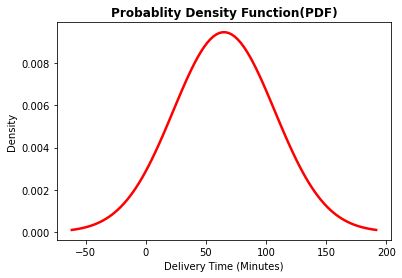

In [168]:
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

mu = df[0].mean()    # 
sigma = df[0].std()   # 

# Create a smooth x-axis sequence spanning 3 standard deviations from the mean
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)


pdf_y = stats.norm.pdf(x, loc=mu, scale=sigma)

#Plot the continuous theoretical PDF line
plt.title("Probablity Density Function(PDF)", fontsize=12, fontweight="bold")
plt.xlabel("Delivery Time (Minutes)")
plt.ylabel("Density")
plt.plot(x, pdf_y, color="red", linewidth=2.5, label=f"Fitted PDF\n(μ={mu:.2f}, σ={sigma:.2f})")


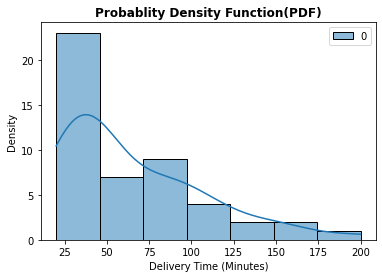

In [172]:
import seaborn as sns

sns.histplot(df,kde=True)

plt.title("Probablity Density Function(PDF)", fontsize=12, fontweight="bold")
plt.xlabel("Delivery Time (Minutes)")
plt.ylabel("Density")
plt.show()